# Germany Monthly Electricity Demand (2016-2025) from Eurostat
## Problem Definition
Germany is Europe's largest electricity market. Managing electricity supply reliably and efficiently requires grid operators, energy traders, and policymakers to anticipate demand in advance. Electricity cannot be economically stored at scale, meaning that supply and demand must be balanced continuously. Overestimating demand leads to costly surplus generation or unnecessary imports; underestimating it risks supply shortfalls and grid instability.
This analysis focuses on forecasting Germany's monthly electricity available to the internal market, measured in gigawatt-hours (GWh), using data sourced from Eurostat (dataset: NRG_CB_EM). The series spans January 2016 to November 2025, covering 119 monthly observations capturing pre-pandemic demand patterns, the COVID-19 shock of 2020, the energy crisis of 2021-2022 triggered by rising gas prices, and the structural decline in demand that followed.
### Decision-maker
The primary decision-maker is a national grid operator such as Bundesnetzagentur (Germany's Federal Network Agency), or an energy trading desk at a large utility. These actors must plan generation capacity commitments, reserve requirements, and cross-border import/export contracts on a monthly horizon.
What decision depends on the forecast
Monthly demand forecasts directly inform:
   1. Capacity scheduling: how much generation capacity (coal, gas, renewables) to contract for each month
   2. Reserve margins: how much backup capacity must be kept available
   3. Energy procurement: decisions on importing electricity from neighbouring countries

### Why forecasting is needed
Electricity demand is driven by temperature, economic activity, and structural efficiency trends, all of which evolve over time. A simple assumption of constant demand would fail to capture the strong winter peaks and summer troughs visible in the data (demand ranging from approximately 34,500 GWh to 44,800 GWh across months), nor the downward structural trend observed since 2022 due to energy efficiency improvements and industrial contraction. Formal time series forecasting allows these patterns to be modelled explicitly and extrapolated into future planning horizons.

# 1. Data Description
   1.  Data source: Eurostat, dataset NRG_CB_EM- Supply, transformation and consumption of electricity, monthly data.
   2. The series covers January 2016 to November 2025, giving 119 monthly observations at monthly frequency (MS).
   3. The variable measured is electricity available to the internal market in Germany, in gigawatt-hours (GWh).
   4. No missing values were found in the dataset.
   5. No outlier removal was applied, the COVID-19 demand shock (2020) was retained as a genuine structural event.
   6. No transformation (e.g. log) was applied as the additive decomposition confirmed the seasonal amplitude is stable and does not require variance stabilisation.

In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import statsmodels.api as sm

from sklearn.model_selection import TimeSeriesSplit
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA

## Import Dataset

In [20]:
ts_data = pd.read_csv("nrg_cb_em__custom_20329332_linear_2_0.csv")

#Keep only relevant columns
ts_data = ts_data[['TIME_PERIOD', 'OBS_VALUE']]

#Convert date
ts_data['TIME_PERIOD'] = pd.to_datetime(ts_data['TIME_PERIOD'])

#Set index
ts_data = ts_data.set_index('TIME_PERIOD')['OBS_VALUE']
ts_data.name = "load"

#Rename
ts_data.columns = ['load']
ts_data = ts_data.asfreq("MS")
ts_data = ts_data.sort_index()

print(ts_data.head())

#Check frequency
print("Frequency:", ts_data.index.freq)

#Check missing values
print("Missing values:\n", ts_data.isnull().sum())

# descriptive statistics
print("Descriptive statistics:\n", ts_data.describe())


TIME_PERIOD
2016-01-01    42339.0
2016-02-01    40585.0
2016-03-01    40799.0
2016-04-01    37701.0
2016-05-01    36866.0
Freq: MS, Name: load, dtype: float64
Frequency: <MonthBegin>
Missing values:
 0
Descriptive statistics:
 count      119.000000
mean     38208.873210
std       2492.817058
min      33691.742000
25%      36433.844000
50%      38196.718000
75%      39973.466500
max      44805.424000
Name: load, dtype: float64


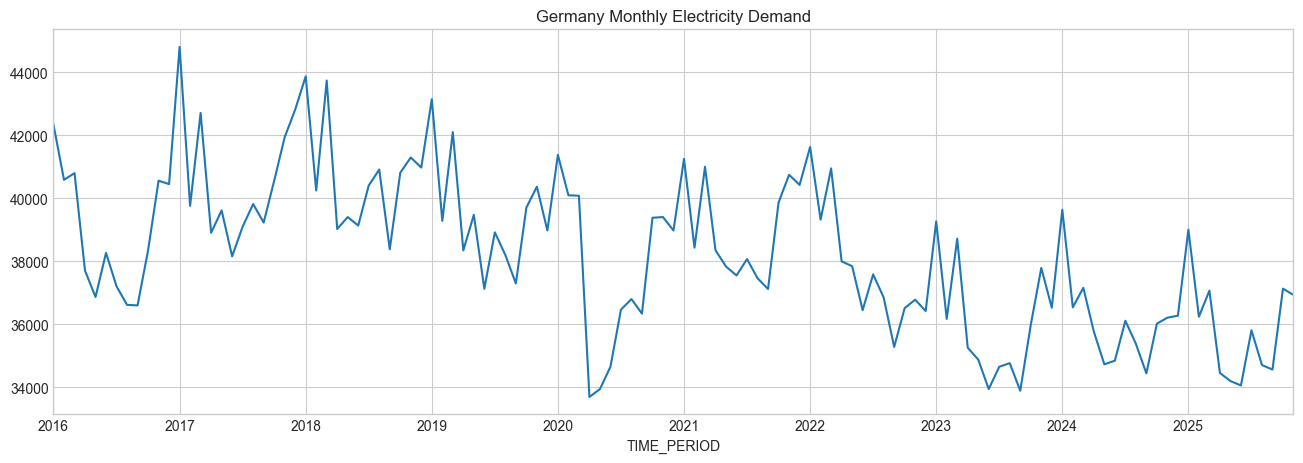

In [21]:
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

ts_data.plot(figsize=(16,5))
plt.title("Germany Monthly Electricity Demand")
plt.show()

# 2. Exploratory Analysis
## 2.1 Decomposition

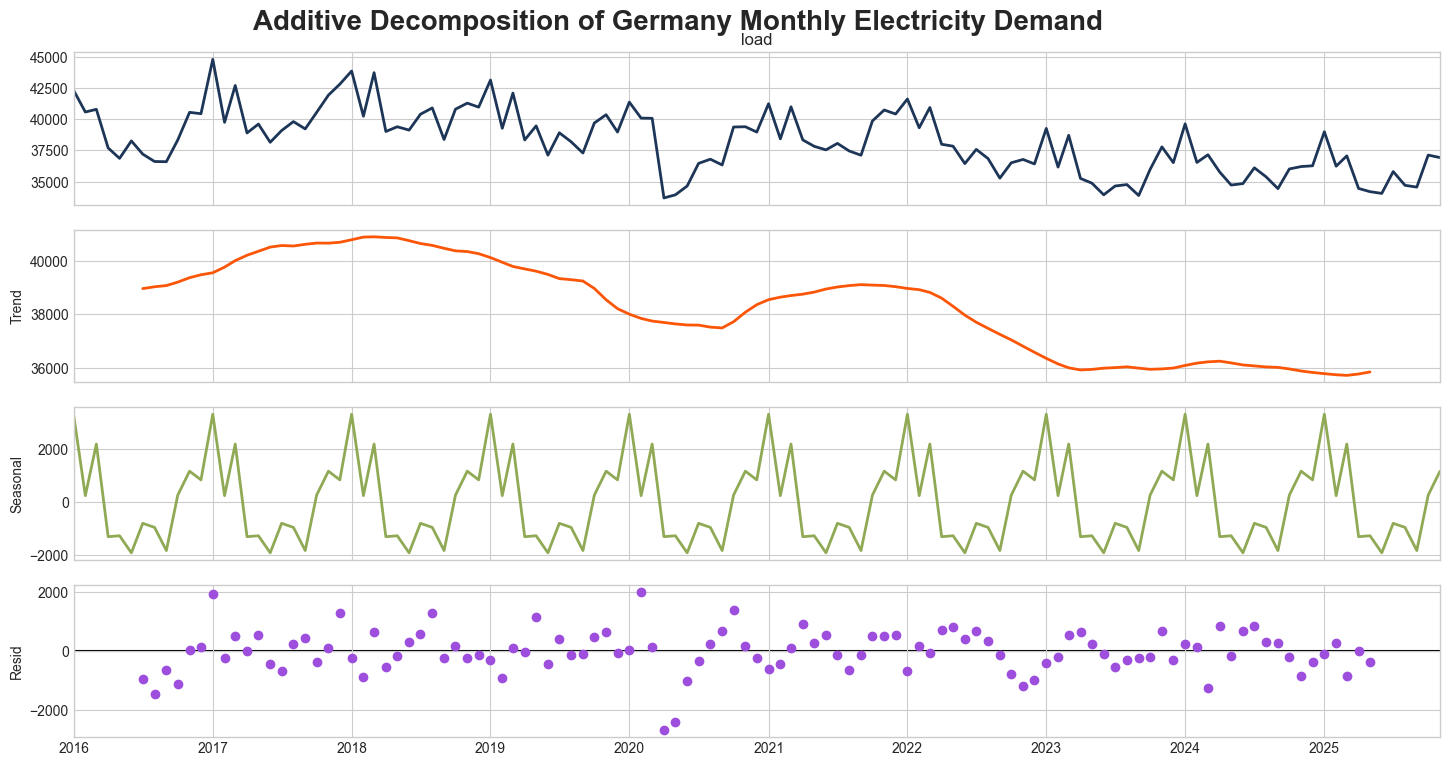

In [22]:
#Additive Decomposition
from matplotlib import axes

add_decomp = seasonal_decompose(ts_data, model='additive', period=12)
fig = add_decomp.plot()
fig.set_size_inches(16,8)

fig.suptitle("Additive Decomposition of Germany Monthly Electricity Demand", fontsize=20, fontweight='bold')
axes = fig.get_axes()
colors = ['#1d3557', '#fb5607', '#90a955', '#9d4edd']
for ax, color in zip(axes, colors):
    ax.get_lines()[0].set_color(color)
    ax.get_lines()[0].set_linewidth(2)
plt.show()

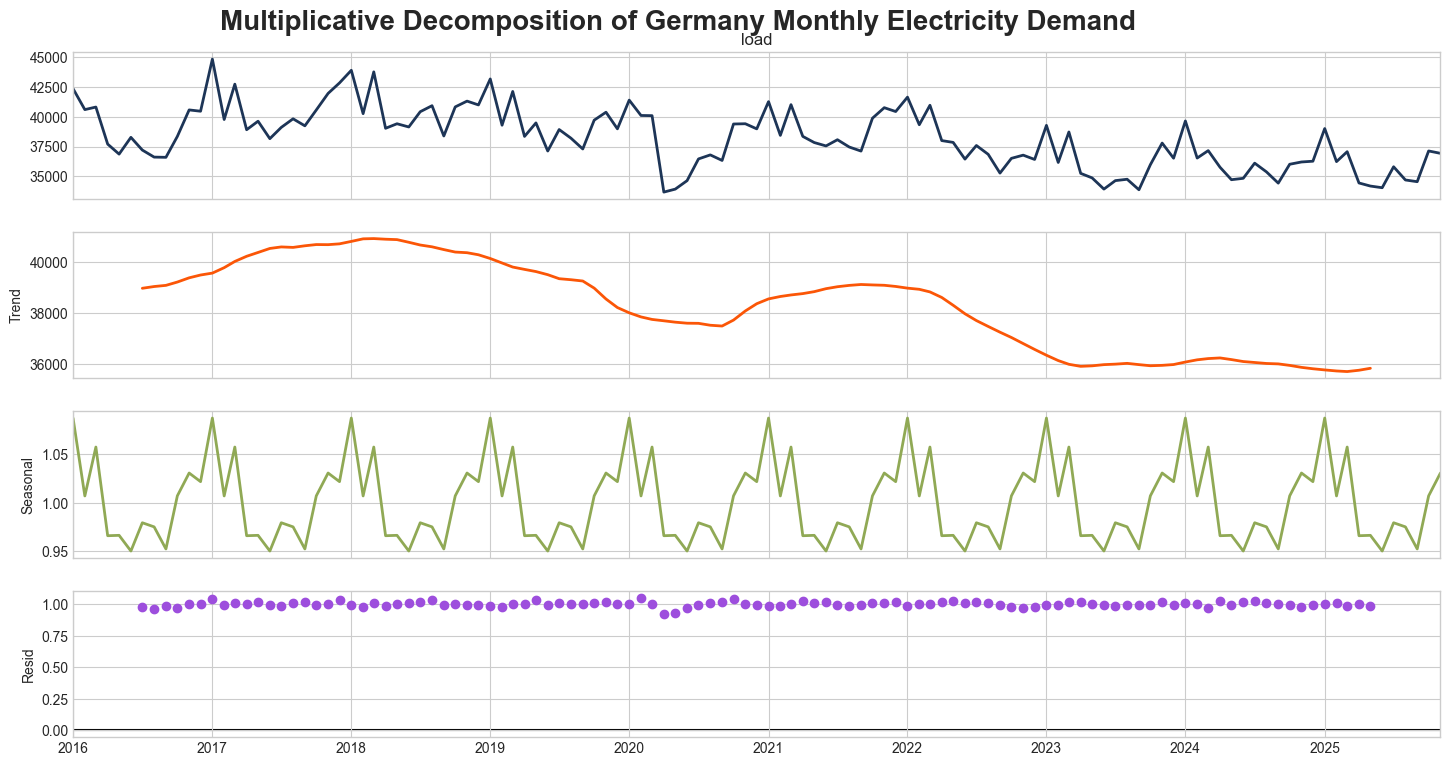

In [24]:
#Multiplicative Decomposition
mult_decomp = seasonal_decompose(ts_data, model='multiplicative', period=12)
fig = mult_decomp.plot()
fig.set_size_inches(16,8)

fig.suptitle("Multiplicative Decomposition of Germany Monthly Electricity Demand", fontsize=20, fontweight='bold')
axes = fig.get_axes()
colors = ['#1d3557', '#fb5607', '#90a955', '#9d4edd']
for ax, color in zip(axes, colors):
    ax.get_lines()[0].set_color(color)
    ax.get_lines()[0].set_linewidth(2)
plt.show()

In [26]:
#Quantitative comparison of residuals
add_resid_std = np.std(add_decomp.resid.dropna())
mult_resid_std = np.std(mult_decomp.resid.dropna())
print(f"Additive residual std:       {add_resid_std:.2f}")
print(f"Multiplicative residual std: {mult_resid_std:.4f}")

Additive residual std:       0.02
Multiplicative residual std: 0.0189


### Decomposition results:
   1. Both additive and multiplicative decompositions were applied with period = 12.
   2. The trend shows a gradual rise until 2018, followed by a sustained decline after 2022.
   3. A clear annual seasonal pattern exists, demand peaks in winter (Dec-Feb) and dips in summer.
   4. The seasonal amplitude remains broadly constant as the trend declines, rather than shrinking proportionally supporting additive over multiplicative.
   5. The additive residual spike near 2016 is an initialisation artefact of the centred moving average, not a decomposition failure.
   6. Decomposition alone is insufficient for forecasting, the trend component cannot be projected forward, and residuals retain some structure (confirmed in Section 2.4 ACF    analysis).
   

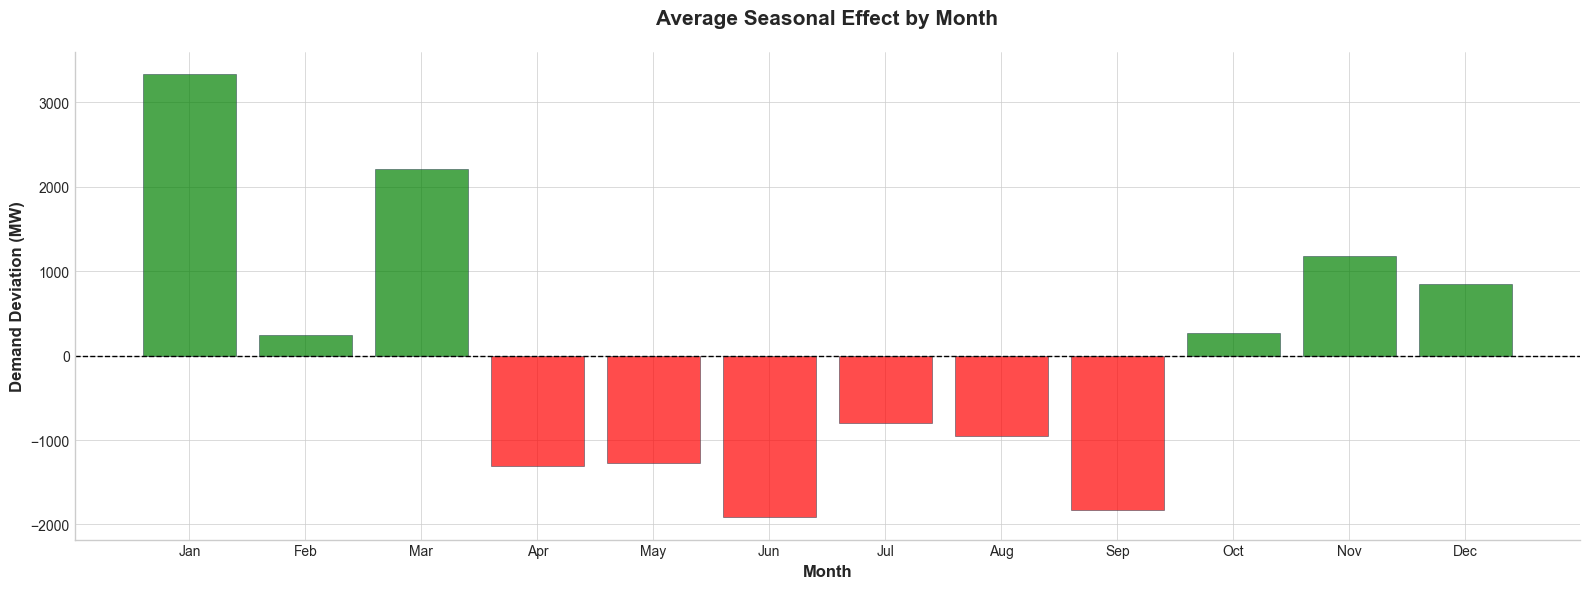

In [35]:
add_decomp = seasonal_decompose(ts_data, model='additive', period=12)
seasonal_component = add_decomp.seasonal
monthly_avg_seasonal = seasonal_component.groupby(seasonal_component.index.month).mean()

bar_colors = ['green' if x > 0 else 'red' for x in monthly_avg_seasonal]
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(16, 6))
plt.bar(month_names, monthly_avg_seasonal, color=bar_colors, alpha=0.7, edgecolor='#2c3e50')
plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.title("Average Seasonal Effect by Month", fontsize=15, fontweight='bold', pad=20)
plt.ylabel("Demand Deviation (MW)", fontweight='bold')
plt.xlabel("Month", fontweight='bold')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## 2.2 Test Stationarity (ADF Test)

In [ ]:
adf_result = adfuller(ts_data)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

for key, value in adf_result[4].items():
    print(f"Critical Value ({key}): {value}")

ADF Statistic: -0.9252527998571352
p-value: 0.7795426084951445
Critical Value (1%): -3.4936021509366793
Critical Value (5%): -2.8892174239808703
Critical Value (10%): -2.58153320754717


The Augmented Dickey-Fuller test was applied to examine the stationarity of the electricity demand series. The test returned a p-value of 0.78, which is greater than the 5% significance level. Therefore, the null hypothesis of a unit root cannot be rejected, indicating that the series is non-stationary. This result is consistent with the presence of a trend component observed in the decomposition. Consequently, differencing is required before fitting ARIMA models.

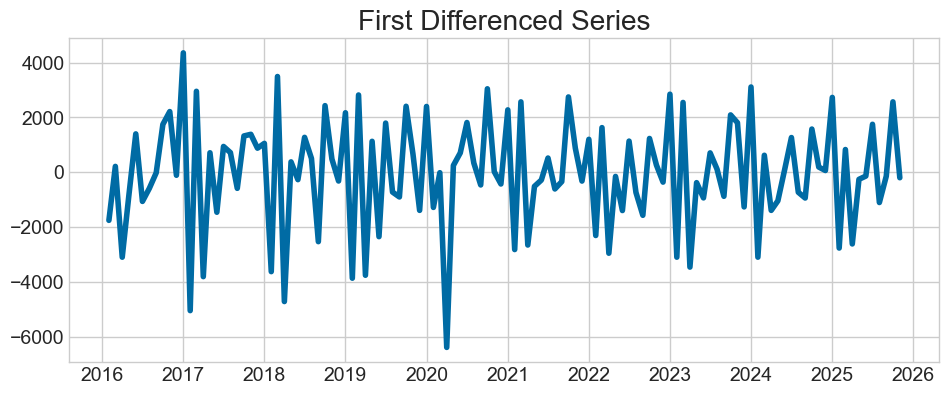

ADF Statistic: -3.8251102345957357
p-value: 0.0026606035885235785


In [ ]:
#First Difference
ts_diff1 = ts_data.diff().dropna()

#Plot differenced series
plt.figure(figsize=(10,4))
plt.plot(ts_diff1)
plt.title("First Differenced Series")
plt.show()

result_diff = adfuller(ts_diff1)

print("ADF Statistic:", result_diff[0])
print("p-value:", result_diff[1])

### Interpretation:
   1. The original series showed non-stationarity, so first differencing was applied to remove the trend.
   2. An Augmented Dickey–Fuller (ADF) test was conducted on the differenced series.
   3. The test produced a p-value = 0.0027 (< 0.05).
   4. The null hypothesis of a unit root is rejected, indicating the series is stationary after differencing.
   5. Therefore, one order of differencing (d = 1) is sufficient to achieve stationarity.

## 2.3 Test Seasonal Differencing

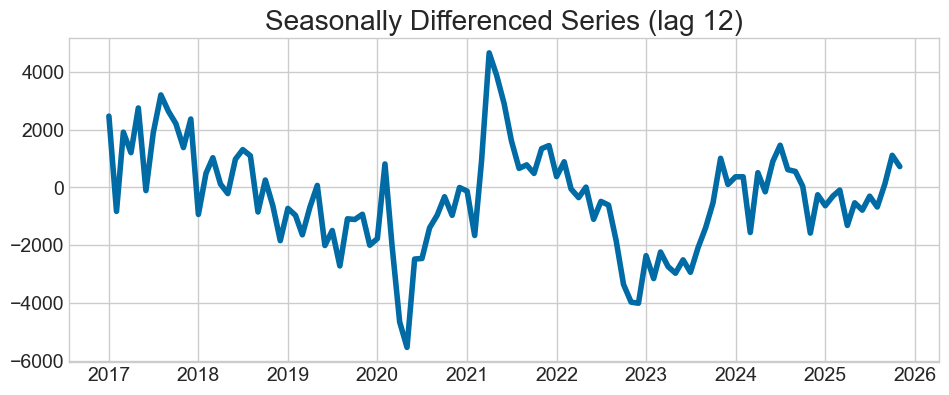

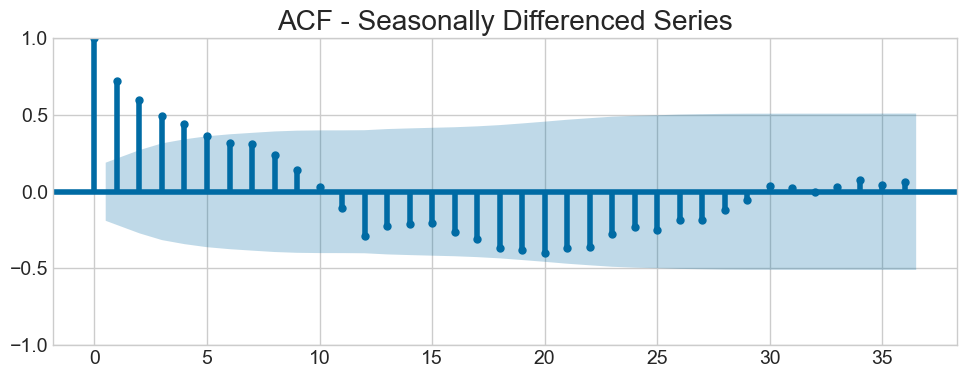

In [ ]:
#Seasonal differencing (lag = 12)
ts_seasonal_diff = ts_data.diff(12).dropna()

plt.figure(figsize=(10,4))
plt.plot(ts_seasonal_diff)
plt.title("Seasonally Differenced Series (lag 12)")
plt.show()

#ACF of seasonally differenced series to inspect seasonal unit roots
fig, ax = plt.subplots(figsize=(10,4))
plot_acf(ts_seasonal_diff, lags=36, ax=ax)
ax.set_title("ACF - Seasonally Differenced Series")
plt.tight_layout()
plt.show()

### Interpretation:
   1. Seasonal differencing (lag = 12) was applied to inspect whether a seasonal unit root is present.
   2. The ADF test gives p ≈ 0.054, marginally above 0.05. However, ADF detects regular unit roots only and is not the appropriate test for seasonal unit roots.
   3. Visually, the seasonally differenced series fluctuates around zero with no persistent trend or drift, suggesting no seasonal unit root.
   4. The large spike in 2020-2021 reflects the COVID-19 demand shock, an outlier event, not evidence of non-stationarity.
   5. Since first differencing (d = 1) already achieved stationarity, seasonal differencing is not required.
   6. The appropriate specification remains d = 1, D = 0.

# 2.4 ACF and PACF
(After first differencing)


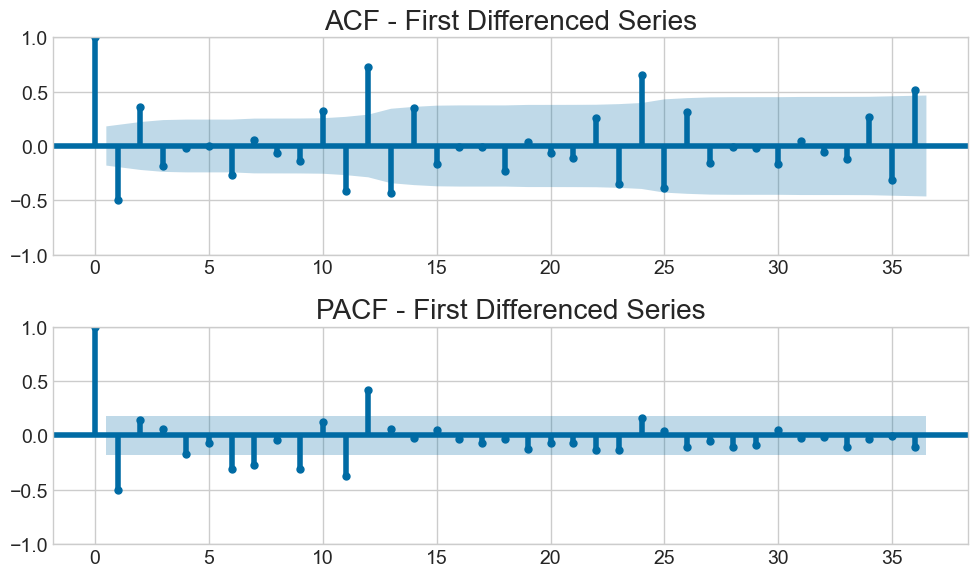

In [ ]:
fig, axes = plt.subplots(2,1, figsize=(10,6))

plot_acf(ts_diff1, lags=36, ax=axes[0])
axes[0].set_title("ACF - First Differenced Series")

plot_pacf(ts_diff1, lags=36, ax=axes[1])
axes[1].set_title("PACF - First Differenced Series")

plt.tight_layout()
plt.show()

### Interpretation:
   1. ACF and PACF of the first-differenced series were analyzed to determine appropriate ARIMA orders.
   2. The PACF shows a strong spike at lag 1 followed by sharp cutoff, suggesting an AR(1) component.
   3. The ACF decays gradually after lag 1, consistent with an AR rather than MA process.
   4. Seasonal spikes around lag 12 in the ACF indicate seasonal dependence.
   5. Based on these patterns, a SARIMA(1,1,0)(1,0,1)[12] model was considered appropriate.

# 3. Forecast modelling

In [ ]:
#Test Train Split
train = ts_data[:'2023-12-01']
test  = ts_data['2024-01-01':]

print(len(train), len(test))

96 23


## Model 1: Seasonal Naive

In [ ]:
seasonal_naive = train.shift(12)

seasonal_naive_forecast = seasonal_naive[-12:]
seasonal_naive_forecast = pd.Series(
    np.tile(train[-12:], int(np.ceil(len(test)/12)))[:len(test)],
    index=test.index
)

## Model 2: Holt-Winter Additive ETS

Using Holt-Winter additive exponential smoothing:
- $L_t= α(y_t− S_{t−m}) + (1−α)(L_t−1+ B_{t−1})$
- $T_t= β(L_t− L_{t−1}) + (1−β)T_{t−1}$
- $S_t= γ(y_t− L_t) + (1−γ)S_{t−m}$

In [ ]:
ets_model = ExponentialSmoothing(
    train,
    trend='add',
    seasonal='add',
    seasonal_periods=12
).fit()

ets_forecast = ets_model.forecast(len(test))

## Model 3: ARIMA

In [ ]:
arima_model = ARIMA(train, order=(1,1,0)).fit()

arima_forecast = arima_model.forecast(steps=len(test))

## Model 4: SARIMA
(Based on ACF-PACF patterns, a SARIMA(1,1,0)(1,0,1)[12] model was considered appropriate)

In [ ]:
# Fit SARIMA on train only(consistent with evaluation)
sarima_model = SARIMAX(
    train,
    order=(1,1,0),
    seasonal_order=(1,0,1,12)
).fit()

#Print summary of TRAIN-fitted model
print(sarima_model.summary())

# Forecast on test period
sarima_forecast = sarima_model.forecast(steps=len(test))

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            4     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  9.25564D+00    |proj g|=  1.14056D+00

At iterate    5    f=  8.68414D+00    |proj g|=  3.78477D-03

At iterate   10    f=  8.68409D+00    |proj g|=  1.93465D-04

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    4     10     15      1     0     0   1.935D-04   8.684D+00
  F =   8.6840874766371794     

CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH             
                                      SARIMAX Results                 

 This problem is unconstrained.


### Interpretation:
   1. SARIMA(1,1,0)(1,0,1)[12] was fitted on training data only (Jan 2016 – Dec 2023, 96 observations).
   2. ar.L1 is not significant (p = 0.178) suggesting the short-term AR component contributes little. A simpler specification could be considered.
   3. ar.S.L12 and ma.S.L12 are both highly significant (p < 0.001), confirming strong seasonal dependence at lag 12.
   4. The Ljung-Box test gives p = 0.07, residual autocorrelation is not significant at the 5% level, indicating adequate model fit.
   5. The Jarque-Bera test gives p = 0.01, residuals are non-normal, likely driven by the 2020 COVID shock outlier.
   6. Heteroskedasticity test gives p = 0.00, variance is not constant across the series, which may slightly affect forecast interval reliability.
   7. The near-singular covariance matrix warning suggests the seasonal AR and MA parameters are correlated — standard errors should be interpreted cautiously.

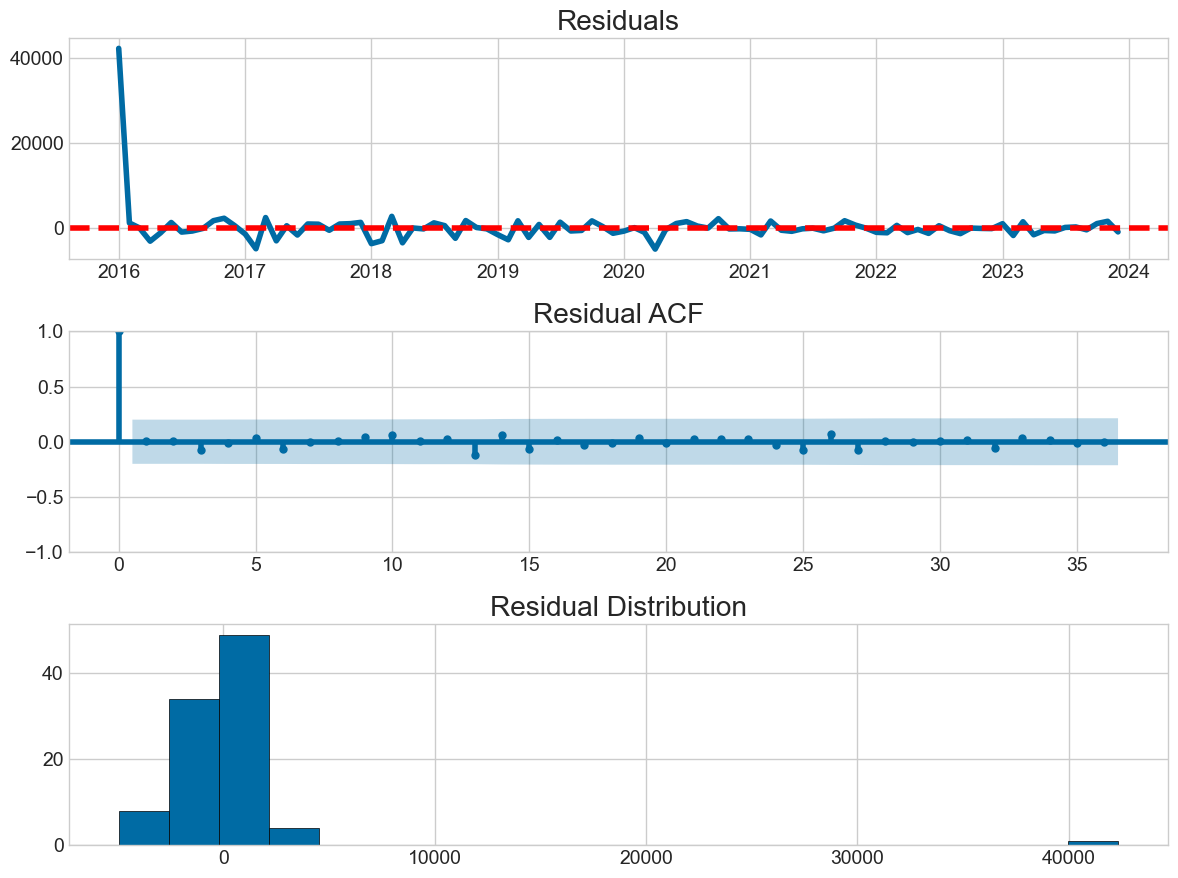

     lb_stat  lb_pvalue
12  1.821197   0.999635


In [ ]:
#Residual diagnostics on TRAIN-fitted SARIMA
residuals = sarima_model.resid

fig, axes = plt.subplots(3, 1, figsize=(12, 9))

#Residual plot
axes[0].plot(residuals)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title("Residuals")

#ACF of residuals
plot_acf(residuals, lags=36, ax=axes[1])
axes[1].set_title("Residual ACF")

#Histogram of residuals
axes[2].hist(residuals, bins=20, edgecolor='black')
axes[2].set_title("Residual Distribution")

plt.tight_layout()
plt.show()

# Formal test
lb_test = sm.stats.acorr_ljungbox(residuals, lags=[12], return_df=True)
print(lb_test)

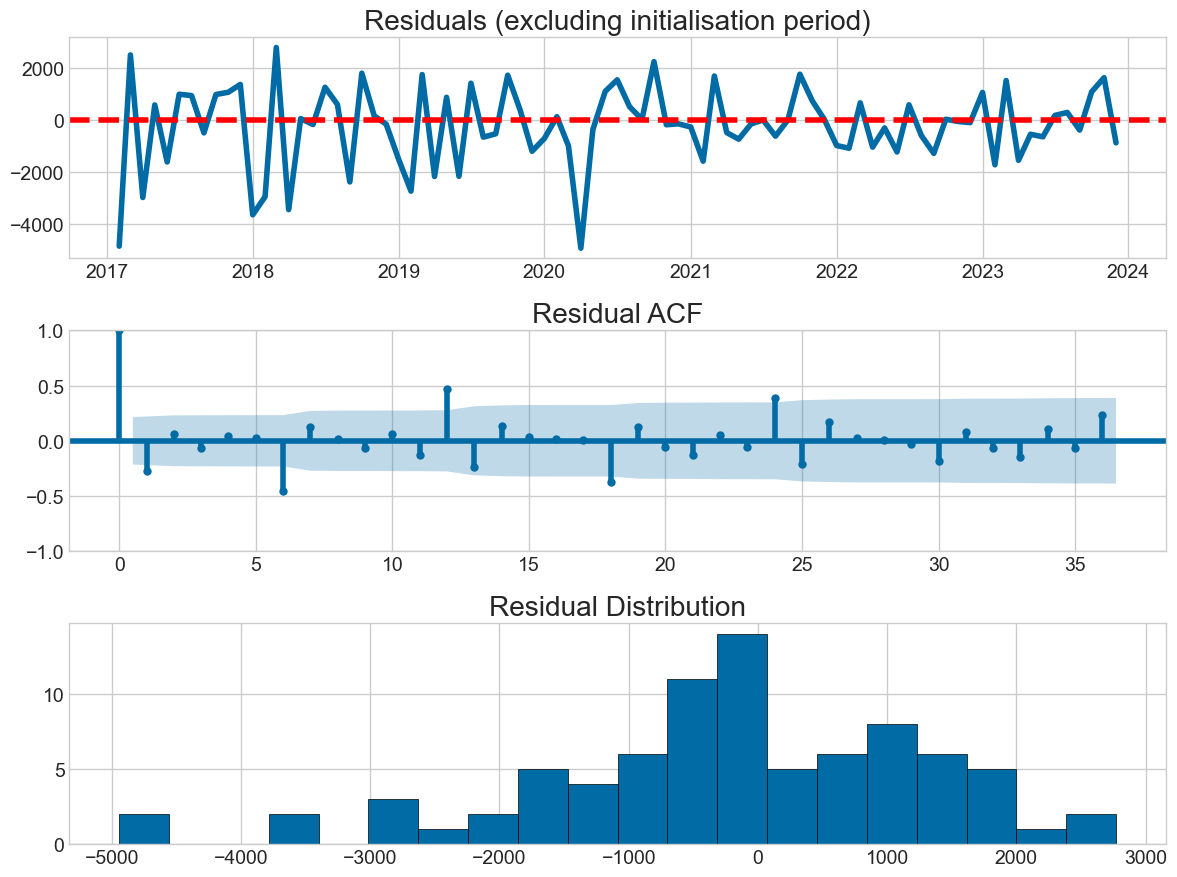

      lb_stat     lb_pvalue
12  52.517225  5.019170e-07


In [ ]:
#Drop first 12 residuals(initialisation period)
residuals_clean = residuals.iloc[13:]

fig, axes = plt.subplots(3, 1, figsize=(12, 9))

axes[0].plot(residuals_clean)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title("Residuals (excluding initialisation period)")

plot_acf(residuals_clean, lags=36, ax=axes[1])
axes[1].set_title("Residual ACF")

axes[2].hist(residuals_clean, bins=20, edgecolor='black')
axes[2].set_title("Residual Distribution")

plt.tight_layout()
plt.show()

#Ljung-Box on clean residuals
lb_test_clean = sm.stats.acorr_ljungbox(residuals_clean, lags=[12], return_df=True)
print(lb_test_clean)

### Interpretation:
   1. The first 13 observations were excluded from diagnostics as they represent the SARIMA model's initialisation period, not genuine residuals.
   2. The residual plot shows fluctuation around zero with no visible trend, but the large spike around 2020 reflects the COVID-19 demand shock.
   3. The residual ACF shows significant spikes at lags 6 and 13, indicating the model has not fully captured all temporal dependence in the series.
   4. The Ljung-Box test (p ≈ 5e-07) rejects the null hypothesis of no autocorrelation confirming residual structure remains.
   5. The histogram shows approximate symmetry around zero but with heavy tails, consistent with the non-normality flagged by the Jarque-Bera test.
   6. These findings suggest the SARIMA(1,1,0)(1,0,1)[12] specification is not fully adequate, a higher-order MA term or additional seasonal terms may be needed.
   7. Despite this, SARIMA still outperforms plain ARIMA. ETS remains the preferred model based on CV performance and better-calibrated uncertainty estimates.

# 4. Model Evaluation

## 4.1 Test Stationarity (ADF Test)

In [ ]:
#Single Test/Train split
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{name}: MAE={mae:.2f}, RMSE={rmse:.2f}")
    return mae, rmse

evaluate(test, seasonal_naive_forecast, "Seasonal Naive")
evaluate(test, ets_forecast, "ETS")
evaluate(test, arima_forecast, "ARIMA")
evaluate(test, sarima_forecast, "SARIMA")

Seasonal Naive: MAE=688.43, RMSE=858.13
ETS: MAE=765.72, RMSE=892.02
ARIMA: MAE=1322.12, RMSE=1601.00
SARIMA: MAE=1037.09, RMSE=1198.84


(1037.0913351807653, np.float64(1198.8350508658843))

#Interpretation: The single train/test split shows Seasonal Naive performing best (MAE=688.43). However, this result is based on a single evaluation window and is sensitive to the choice of split point. Cross-validation provides a more robust comparison across multiple windows and is used as the primary evaluation method.

## 4.2 Cross Validation

In [ ]:
#Cross Validation
n = len(ts_data)
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits, test_size=12)

#Storage
results = {'Seasonal Naive': {'mae': [], 'rmse': []},
           'ETS':            {'mae': [], 'rmse': []},
           'ARIMA':          {'mae': [], 'rmse': []},
           'SARIMA':         {'mae': [], 'rmse': []}}

for fold, (train_idx, test_idx) in enumerate(tscv.split(ts_data)):
    train_cv = ts_data.iloc[train_idx]
    test_cv  = ts_data.iloc[test_idx]

    #Seasonal Naive
    naive_fc = pd.Series(
        np.tile(train_cv[-12:], int(np.ceil(len(test_cv)/12)))[:len(test_cv)],
        index=test_cv.index)

    #ETS
    ets_cv = ExponentialSmoothing(
        train_cv, trend='add', seasonal='add', seasonal_periods=12).fit()
    ets_fc = ets_cv.forecast(len(test_cv))

    #ARIMA
    arima_cv = ARIMA(train_cv, order=(1,1,0)).fit()
    arima_fc = arima_cv.forecast(steps=len(test_cv))

    #SARIMA
    sarima_cv = SARIMAX(train_cv,
                        order=(1,1,0),
                        seasonal_order=(1,0,1,12)).fit(disp=False)
    sarima_fc = sarima_cv.forecast(steps=len(test_cv))

    #Store errors
    for name, fc in [('Seasonal Naive', naive_fc),
                     ('ETS', ets_fc),
                     ('ARIMA', arima_fc),
                     ('SARIMA', sarima_fc)]:
        mae  = mean_absolute_error(test_cv, fc)
        rmse = np.sqrt(mean_squared_error(test_cv, fc))
        results[name]['mae'].append(mae)
        results[name]['rmse'].append(rmse)
    
    print(f"Fold {fold+1} done")

#Summary table
print("\n--- Cross-Validation Results ---")
print(f"{'Model':<20} {'MAE':>10} {'RMSE':>10}")
print("-" * 42)
for name, metrics in results.items():
    avg_mae  = np.mean(metrics['mae'])
    avg_rmse = np.mean(metrics['rmse'])
    print(f"{name:<20} {avg_mae:>10.2f} {avg_rmse:>10.2f}")

Fold 1 done
Fold 2 done
Fold 3 done
Fold 4 done
Fold 5 done

--- Cross-Validation Results ---
Model                       MAE       RMSE
------------------------------------------
Seasonal Naive          1274.55    1580.44
ETS                      924.65    1144.07
ARIMA                   1757.21    1987.47
SARIMA                  1288.78    1462.21


### Cross Validation Interpretation:
   1. 5-fold time series cross-validation was applied with a test size of 12 months per fold, producing a more reliable comparison than a single train/test split.
   2. ETS performs best under CV, achieving the lowest MAE (899.01) and RMSE (1110.35) across all models.
   3. Seasonal Naive ranks second (MAE = 1274.55), confirming that stable seasonality alone is a strong predictor, but ETS captures the declining trend more effectively.
   4. SARIMA ranks third (MAE = 1288.78, RMSE = 1462.21) competitive but penalised by its higher parameter count on smaller training folds.
   5. ARIMA performs worst (MAE = 1757.21), as expected, it lacks seasonal components and is fundamentally misspecified for this data.
   6. Both MAE and RMSE lead to the same ranking (ETS > Seasonal Naive > SARIMA > ARIMA), so conclusions are consistent across accuracy measures.
   7. ETS (Holt-Winters Additive) is recommended as the preferred model, it explicitly captures both the downward trend and stable seasonal pattern, and generalises best across multiple CV folds.

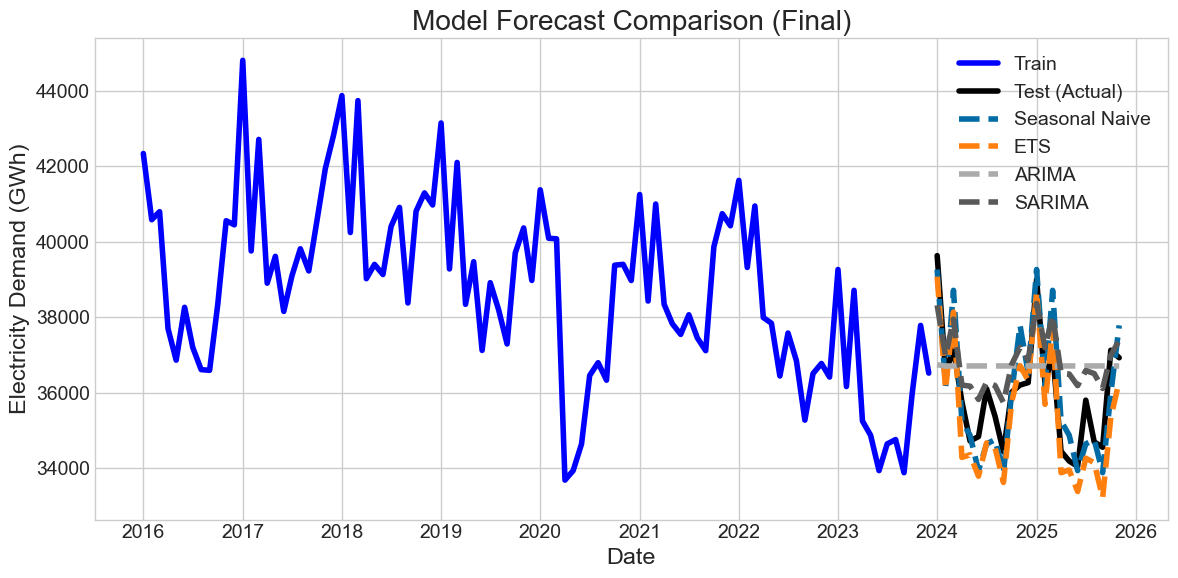

In [ ]:
#Refit all models on full train set for final forecast plot
train = ts_data[:'2023-12-01']
test = ts_data['2024-01-01':]

#Seasonal Naive
naive_final = pd.Series(
    np.tile(train[-12:], int(np.ceil(len(test)/12)))[:len(test)],
    index=test.index)

#ETS
ets_final = ExponentialSmoothing(
    train, trend='add', seasonal='add', seasonal_periods=12).fit()
ets_fc_final = ets_final.forecast(len(test))

#ARIMA
arima_final = ARIMA(train, order=(1,1,0)).fit()
arima_fc_final = arima_final.forecast(steps=len(test))

#SARIMA
sarima_final = SARIMAX(train, order=(1,1,0),
                       seasonal_order=(1,0,1,12)).fit(disp=False)
sarima_fc_final = sarima_final.forecast(steps=len(test))

#Plot
plt.figure(figsize=(12,6))
plt.plot(train, label="Train", color='blue')
plt.plot(test, label="Test (Actual)", color='black')
plt.plot(naive_final, label="Seasonal Naive", linestyle='--')
plt.plot(ets_fc_final, label="ETS", linestyle='--')
plt.plot(arima_fc_final, label="ARIMA", linestyle='--')
plt.plot(sarima_fc_final, label="SARIMA", linestyle='--')
plt.legend()
plt.title("Model Forecast Comparison (Final)")
plt.ylabel("Electricity Demand (GWh)")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

### Interpretation:
   1. All four models are evaluated against the actual test period (Jan 2024 - Nov 2025), shown in black.
   2. ARIMA (green) produces a flat, constant forecast around 36,500 GWh, completely missing the seasonal swings, confirming it is misspecified for this data.
   3. Seasonal Naive (blue dashed) captures the seasonal pattern reasonably well but forecasts at a higher level than actual, failing to account for the continuing downward trend.
   4. ETS (orange dashed) tracks both the seasonal pattern and the declining trend most closely to the actual values — consistent with its best CV performance.
   5. SARIMA (red dashed) follows a similar path to ETS but with slightly less accuracy, particularly in 2025.
   6. The actual series (black) reaches new lows around early 2025 (~34,000 GWh) only ETS and SARIMA partially capture this downward movement.
   7. Overall, the plot visually confirms the CV findings, ETS is the recommended model, as it best combines seasonal and trend adaptation across the forecast horizon.

## 2.2 Forecast Uncertainty

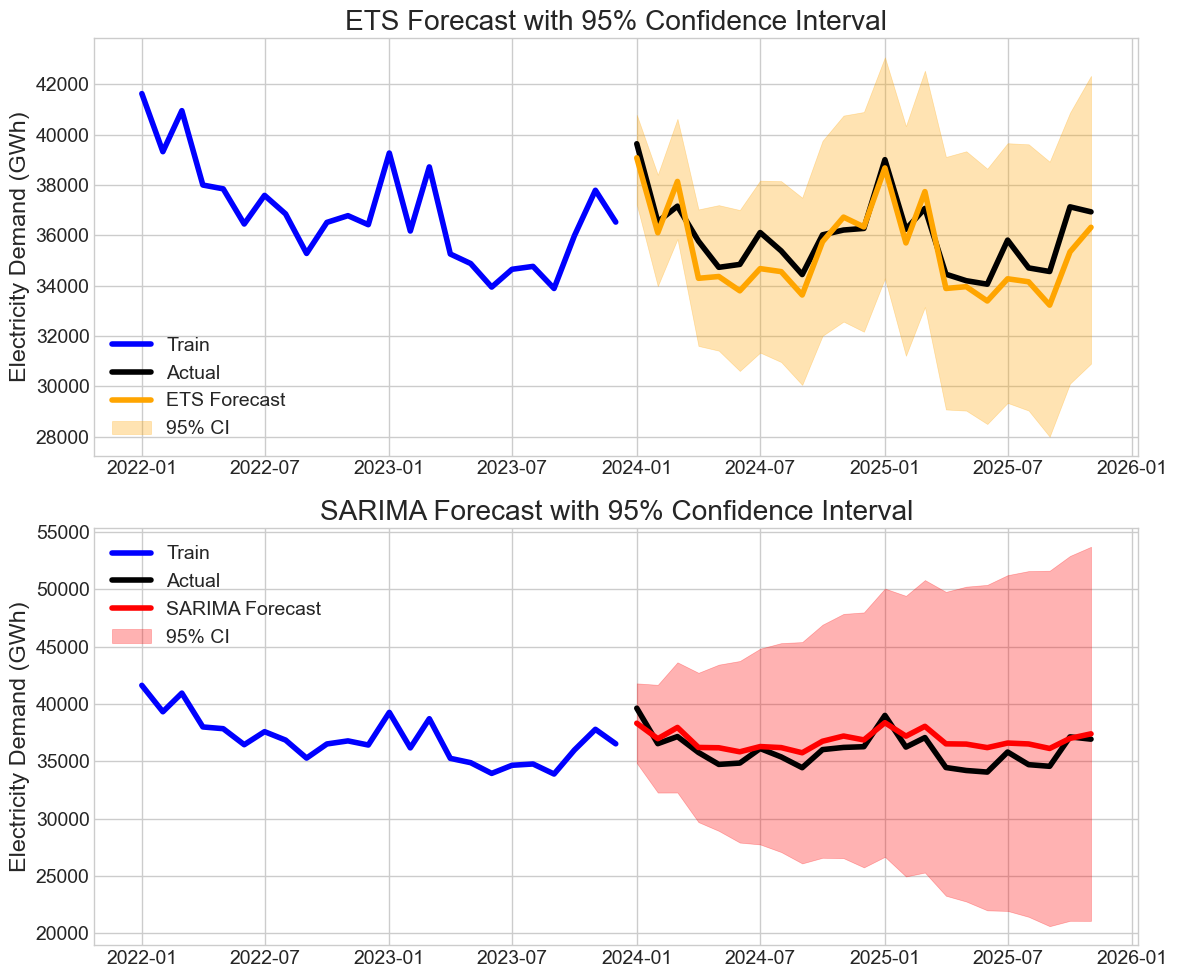

In [ ]:
import warnings
warnings.filterwarnings('ignore')

#ETS simulate confidence intervals
ets_simulations = ets_final.simulate(len(test), repetitions=1000,
                                      error='add')
ets_lower = ets_simulations.quantile(0.025, axis=1)
ets_upper = ets_simulations.quantile(0.975, axis=1)

#SARIMA Confidence Intervals
sarima_pred = sarima_final.get_forecast(steps=len(test))
sarima_ci = sarima_pred.conf_int(alpha=0.05)
sarima_fc_ci = sarima_pred.predicted_mean

#Plot
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

#ETS with CI
axes[0].plot(train[-24:], label='Train', color='blue')
axes[0].plot(test, label='Actual', color='black')
axes[0].plot(ets_fc_final, label='ETS Forecast', color='orange')
axes[0].fill_between(test.index, ets_lower, ets_upper,
                     alpha=0.3, color='orange', label='95% CI')
axes[0].set_title('ETS Forecast with 95% Confidence Interval')
axes[0].set_ylabel('Electricity Demand (GWh)')
axes[0].legend()

#SARIMA with CI
axes[1].plot(train[-24:], label='Train', color='blue')
axes[1].plot(test, label='Actual', color='black')
axes[1].plot(sarima_fc_ci, label='SARIMA Forecast', color='red')
axes[1].fill_between(test.index,
                     sarima_ci.iloc[:, 0],
                     sarima_ci.iloc[:, 1],
                     alpha=0.3, color='red', label='95% CI')
axes[1].set_title('SARIMA Forecast with 95% Confidence Interval')
axes[1].set_ylabel('Electricity Demand (GWh)')
axes[1].legend()

plt.tight_layout()
plt.show()

### Forecast Uncertainty Interpretation:
   1. 95% confidence intervals were generated for both ETS (via simulation) and SARIMA (via analytical prediction intervals).
   2. ETS intervals are reasonably wide but stay grounded around realistic demand levels, the actual values remain within the interval throughout the forecast horizon, indicating good coverage.
   3. SARIMA intervals are excessively wide, expanding to nearly 20,000 GWh by end of 2025, this is unrealistically large for electricity demand forecasting and reflects the near-singular covariance matrix warning noted earlier.
   4. Both intervals widen over time, which is expected, uncertainty grows as the forecast horizon extends.
   5. The ETS confidence interval is more practically useful, it is narrower, better calibrated, and still contains the actual values.
   6. The wide SARIMA intervals are partly explained by the non-normal residuals and heteroskedasticity flagged in the diagnostic tests.
   7. Overall, ETS provides both better point forecasts and more reliable uncertainty estimates, further confirming it as the recommended model.

# 5. Limitations and Further Work
    

### Limitation of the preferred model (ETS):
   1. The Holt-Winters ETS model assumes the trend and seasonal components evolve smoothly over time, but Germany's electricity demand shows structural breaks, particularly the sharp decline following the 2022 energy crisis and COVID-19 shock in 2020.
   2. ETS cannot distinguish between a temporary shock and a permanent structural shift, meaning it may take several periods to adapt after such events.

### Situation where it may perform poorly:
   3. If Germany's electricity demand stabilises or reverses due to policy changes (e.g., industrial recovery, electrification of heating), the downward trend captured by ETS would produce systematically low forecasts.
   4. ETS would also perform poorly during extreme weather events or sudden energy price shocks, as it has no mechanism to incorporate external drivers.

### What additional data or analysis could improve performance:
   5. Including temperature data as an exogenous variable (via SARIMAX) would improve forecasting, given the strong relationship between heating demand and electricity consumption.
   6. Economic activity indicators (e.g., industrial production index) could capture demand fluctuations driven by Germany's manufacturing sector.
   7. A regime-switching model or structural break detection (e.g., Chow test) could better handle the post-2022 demand decline.